Python (core + DS)

# Language & internals

1.	What’s the difference between a list, tuple, set, and dict—runtime and typical use cases?
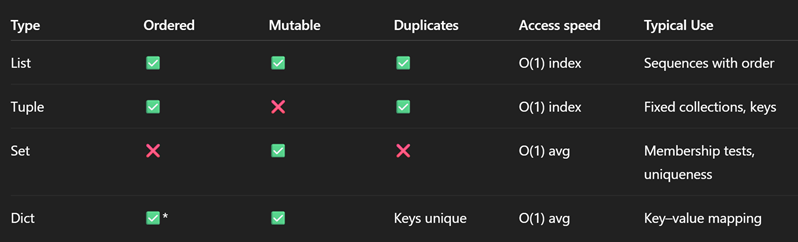

2.	Explain mutability and how it affects default arguments (def f(x=[]):). How do you fix it?

•  Mutable objects (like lists, dicts, sets) can be changed in place (e.g., append, update).</br>
•  Immutable objects (like ints, floats, strings, tuples) cannot be modified — creating a “new” object instead.


In [ ]:
def f(x=[]):
    x.append(1)
    return x
print(f())  # [1]
f() # [1, 1]

# Fix the code
def f(x=None):
    if x is None:
        x = []
    x.append(1)
    return x

[1]


[1, 1]

3.	How does Python’s GIL affect CPU-bound vs I/O-bound code? When would you choose multiprocessing, threading, asyncio?

Python's Global Interpreter Lock (GIL) is a mutex that protects access to Python objects, preventing multiple native threads from executing Python bytecodes at once. This means only one thread can be in a "running" state at any given time, regardless of the number of CPU cores available.</br>
- CPU-bound code is code that spends most of its time performing intensive computations, like numerical calculations or data processing. For this type of code, the GIL is a significant bottleneck. Since only one thread can execute Python bytecode at a time, a multi-threaded Python program won't run any faster on a multi-core machine than a single-threaded one. In fact, it might even be slower due to the overhead of context switching between threads.</br>
- I/O-bound code is code that spends most of its time waiting for external operations to complete, like network requests, disk reads, or database queries. For this type of code, the GIL is less of a concern. When a thread is waiting for an I/O operation, the GIL is released, allowing another thread to acquire it and run. This enables concurrency, as one thread can be doing useful work while another is blocked, waiting for I/O
</br>
- Multiprocessing (ideal choice for CPU-bound) creates new processes, each with its own Python interpreter and memory space. Since each process has its own GIL, they can run on different CPU cores simultaneously, making it the ideal choice for CPU-bound tasks. It allows you to bypass the GIL entirely and achieve true parallelism.</br>
- Threading ( excellent one for I/O-bound) uses multiple threads within a single process, sharing the same memory space and the GIL. This makes it a poor choice for CPU-bound tasks but an excellent one for I/O-bound tasks. Threads are lightweight and efficient for concurrent operations where the program spends most of its time waiting.


4.	Big-O for membership tests in list vs set vs dict. List: O(n), set: O(1) Sets are implemented using a hash table, dict O(1)

5.	How does @property work? When would you use descriptors/dataclasses/__slots__?

In [ ]:
# Pythonic way to provide a cleaner, more readable interface to instance attributes.
class Circle:
    def __init__(self, radius):
        self._radius = radius
    @property
    def radius(self):
        """The radius property getter."""
        return self._radius
    
    @radius.setter
    def radius(self,value):
        """The radius property setter."""
        if value<0:
            raise ValueError("Radius should be positive")
        self._radius=value
c = Circle(6)
print(c.radius) 
c.radius = 4
print(c.radius)


6
4


6. What are context managers? Implement one without @contextmanager

A context manager defines a runtime context for a block of code using the with statement. It ensures that setup and teardown logic always run, even if exceptions occur.

7.	Explain deep copy vs shallow copy; when do you need each?
“A shallow copy only duplicates the outer container, so inner objects are still shared. A deep copy duplicates everything recursively, so you get a fully independent clone. I use shallow copies for flat or intentionally shared structures, and deep copies when I need safe, independent objects.”

8.	How does method resolution order (MRO) work in multiple inheritance?

- Start with the current class.
- Then check its parents (left to right).
- Then check their parents, merging while preserving order.

In [33]:
class A:
    def whoami(self): return "A"

class B(A):
    def whoami(self): return "B"

class C(A):
    def whoami(self): return "C"

class D(B, C):
    pass

print(D.mro())
print(D().whoami())

[<class '__main__.D'>, <class '__main__.B'>, <class '__main__.C'>, <class '__main__.A'>, <class 'object'>]
B


9.	What’s the difference between == and is, and where do interns get this wrong?

In [ ]:
a = [1, 2, 3]
b = [1, 2, 3]
x=True
print(a == b)   #✅ True  (same contents)
print(a is b)   # False (different objects, even though contents match)
print(a is a)   # True  (same reference)


# ✅ Identity checks 
a is None
x is True
x is False

# Checking sentinel objects 
if result is NOT_FOUND:

10.	How do you structure a package for a production library (layout, __init__, versioning, pyproject.toml)?

In [ ]:
"""
your-lib/
├─ pyproject.toml
├─ README.md
├─ LICENSE
├─ CHANGELOG.md
├─ .gitignore
├─ .editorconfig
├─ src/
│  └─ your_lib/
│     ├─ __init__.py
│     ├─ _version.py
│     ├─ core.py
│     ├─ utils.py
│     ├─ py.typed              # if you ship type hints
│     └─ data/                 # package data (if any)
├─ tests/
│  ├─ __init__.py
│  └─ test_core.py
├─ docs/                       # optional
└─ scripts/                    # optional CLIs/dev tools
"""

# src/your_lib/__init__.py
from .core import Foo, Bar        # curated imports (public API) 
# Stable public API: only export from __init__. Everything else is private.
from ._version import __version__ # single source of truth (MAJOR.MINOR.PATCH)"0.3.1"

__all__ = ["Foo", "Bar", "__version__"]

11.	Explain type hints in large codebases: Protocol, TypedDict, Union/Literal, pydantic vs stdlib typing.

In [ ]:
from typing import TypeVar, Sequence, Iterable
# Generics / TypeVar
T = TypeVar("T")

def batched(xs: Sequence[T], n: int) -> Iterable[Sequence[T]]:
    # Preserves element types through your APIs (e.g., Sequence[int] -> Iterable[Sequence[int]]).
    for i in range(0, len(xs), n):
        yield xs[i:i+n]

A descriptor is a protocol that allows an object to customize attribute access. It's an object that implements at least one of the __get__, __set__, or __delete__ methods. @property is actually built on top of the descriptor protocol.

You'd use a descriptor when you need to reuse the same access-control logic across multiple classes or attributes. For example, a descriptor could be used to validate an email address for multiple different user classes without rewriting the validation logic each time.

In [29]:
from dataclasses import dataclass

@dataclass
class Point:
    x: float
    y: float

p = Point(1.0, 2.0)
print(p) # Point(x=1.0, y=2.0)

Point(x=1.0, y=2.0)


12.	How do you write unit tests and property-based tests (pytest + hypothesis)?
13.	Techniques to speed up Python: vectorization, C extensions, Numba, Cython, PyPy—trade-offs.
14.	Memory profiling: tools and strategies (tracemalloc, objgraph). “For memory profiling I usually start with tracemalloc to see where allocations happen, and objgraph to trace why objects aren’t released. For line-by-line usage I add memory_profiler. In DS pipelines I also enforce efficient dtypes, chunked reads, and avoid creating unnecessary copies.”

15.	How would you design an API client module with retries, timeouts, and circuit breakers?

- Transport: use httpx (sync/async) for per-request connect/read timeouts and connection pooling.
- Retries: exponential backoff with jitter; retry only idempotent methods (GET, HEAD, some PUT/DELETE) and retryable status codes (502/503/504, maybe 429 with Retry-After).
- Circuit breaker: track recent failures; transition CLOSED → OPEN after a threshold; after cooldown, go HALF_OPEN and allow a probe; success - closes it, failure re-opens.
- Observability: structured logs, counters (success/failure, open/close events), latency histograms.
- Config: inject via dataclass/env; never hardcode.
- Testability: isolate breaker + retry logic; mock transport; deterministically seed jitter.

# Data wrangling & numerics

In [34]:
import pandas as pd
prices = pd.DataFrame({
    "time": pd.to_datetime(["09:00","09:05","09:10"]),
    "price": [100, 101, 102]
})
trades = pd.DataFrame({
    "time": pd.to_datetime(["09:01","09:06"]),
    "qty": [5, 10]
})
pd.merge_asof(trades, prices, on="time", direction="backward")

C:\Users\mamma\AppData\Local\Temp\ipykernel_31244\1162525599.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  "time": pd.to_datetime(["09:00","09:05","09:10"]),
C:\Users\mamma\AppData\Local\Temp\ipykernel_31244\1162525599.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  "time": pd.to_datetime(["09:01","09:06"]),


,time,qty,price
0,2025-09-08 09:01:00,5,100
1,2025-09-08 09:06:00,10,101


In [38]:
df = pd.DataFrame({"id":([1,2],(3,4)), "tags":[["a","b"],["c"]]})
print(df)
df.explode("tags")

       id    tags
0  [1, 2]  [a, b]
1  (3, 4)     [c]


,id,tags
0,"[1, 2]",a
0,"[1, 2]",b
1,"(3, 4)",c


In [42]:
df.explode("tags").explode("id")

,id,tags
0,1,a
0,2,a
0,1,b
0,2,b
1,3,c
1,4,c


- Unit Tests: Test: the smallest pieces of code (functions, classes, methods) in isolation to verify correctness of a single unit’s logic.
- regression test: Ensure old bugs don’t come back (“regress”)
- integration test: Test how multiple components work together. Example: Run an ETL → feature pipeline → model prediction end to end, check row counts, schema, and predictions.

# Algorithms